<a href="https://colab.research.google.com/github/pixi2102/iad-intro-ds/blob/master/_hw06_texts_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:

df = pd.read_csv('/content/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
13650,20363,65315,International,22-03-2020,Finally in stock! Intenst 60ML Moisturizing Ha...,Positive
20390,28679,73631,NaN,27-03-2020,"Mahavir Temple trust 1 crore,\r\r\nMahamaya Te...",Negative
5859,10915,55867,Redditch,19-03-2020,stop panic buying you mongs\r\r\n\r\r\nhttps:/...,Extremely Negative
19963,28135,73087,"Bowling Green, OH",26-03-2020,Great video! I feel like my kitchen is clean a...,Extremely Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df['Sentiment'].unique()

array(['Positive', 'Extremely Negative', 'Negative', 'Extremely Positive'],
      dtype=object)

In [4]:
def convert(word):
    if word in ['Positive', 'Extremely Positive']:
        return 1
    elif word in ['Negative', 'Extremely Negative']:
        return 0
df['Sentiment'] = df['Sentiment'].apply(convert)# -- YOUR CODE HERE --

Сбалансированы ли классы?

In [5]:
df['Sentiment'].value_counts()
# -- YOUR CODE HERE --

,count
Sentiment,
1,18046
0,15398


**Ответ:** Видим, что 18046  и 15398 отличаются меньше, чем на 20%, то есть можем считать классы сбалансированными.

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [6]:
df.isnull().sum()# -- YOUR CODE HERE --

,0
UserName,0
ScreenName,0
Location,7049
TweetAt,0
OriginalTweet,0
Sentiment,0


In [7]:
df.fillna('Unknown', inplace=True)

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df,test_size=0.3,random_state=0)# -- YOUR CODE HERE --

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [9]:
from collections import Counter
def tokenize(text):
    return text.lower().split()
token_counter = Counter()

for text in train['OriginalTweet']:
    tokens = tokenize(text)
    token_counter.update(tokens)


Какой размер словаря получился?

In [10]:
len(token_counter)# -- YOUR CODE HERE --

79755

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [11]:
for token, count in token_counter.most_common(10):
    print(f"Токен: '{token}', Количество встреч: {count}")# -- YOUR CODE HERE --

Токен: 'the', Количество встреч: 26815
Токен: 'to', Количество встреч: 23373
Токен: 'and', Количество встреч: 14684
Токен: 'of', Количество встреч: 13012
Токен: 'a', Количество встреч: 11737
Токен: 'in', Количество встреч: 11198
Токен: 'for', Количество встреч: 8566
Токен: '#coronavirus', Количество встреч: 8223
Токен: 'is', Количество встреч: 7383
Токен: 'are', Количество встреч: 7050


**Ответ:** Видим, что среди самых популярных токенов есть предлоги (to,in, for, и тд), союзы (and) и артикли (the, a). Это логично, так как без них почти невозможно построить предложение. Также среди популярных токенов есть глаголы связки (are, is) -- это одни из самых популярных глаголов в английском. Особенно выделяется токен #coronovirus -- думаю, это связано с выборкой твитов, возможно они брались в 2019-2022 году, когда тема пандемии была очень актуальна.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def tokenize(text):
    tokens = text.lower().split()
    return [token for token in tokens if token not in stop_words]
token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for token, count in token_counter.most_common(10):
    print(f"Токен: '{token}', Количество встреч: {count}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Токен: '#coronavirus', Количество встреч: 8223
Токен: 'prices', Количество встреч: 3891
Токен: 'food', Количество встреч: 3820
Токен: 'grocery', Количество встреч: 3469
Токен: 'supermarket', Количество встреч: 3288
Токен: 'people', Количество встреч: 3175
Токен: 'covid-19', Количество встреч: 3173
Токен: 'store', Количество встреч: 3155
Токен: '#covid19', Количество встреч: 2471
Токен: '&amp;', Количество встреч: 2314


**Ответ:**  Видим, что теперь среди самых популярных слов в основном существительные, которые часто используются в повседневной жизни (люди, супермаркет, еда, магазин и так далее). Также много слов с участием коронавируса, так как это было острой темой.

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [13]:
for token, count in token_counter.most_common()[-20:]:
    print(f"{token}: {count}")# -- YOUR CODE HERE --

skellig: 1
coast!: 1
closer!): 1
@skelligsix18: 1
#skelligcoast2kms: 1
#southkerry: 1
https://t.co/zjcl195vqs: 1
@srinivasiyc: 1
https://t.co/iaek4fwsgz: 1
premiership: 1
non-playing: 1
subsidise: 1
playersãâ: 1
renewing: 1
wage!: 1
flew: 1
nothing...: 1
@torontopearson: 1
@680news: 1
https://t.co/7j2y3rsld9: 1


**Ответ:** Видим, что среди непопулярных токенов есть ссылки на сайты, слова с опечатками, никнеймы и редкие термины (например subsidise). Может быть было бы полезно удалить токены, начинающиеся с @ или https:// (никнеймы и ссылки на сайты), а также токены содержащие необычные символы (вроде playersãâ) и знаки препинания.



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [14]:
from nltk.tokenize import TweetTokenizer
def tokenize(text):
    tokenizer = TweetTokenizer()
    return tokenizer.tokenize(text.lower())

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for token, count in token_counter.most_common(10):
    print(f"{token}: {count}")

the: 26993
.: 24118
to: 23478
,: 17571
and: 14825
of: 13044
a: 11891
in: 11348
?: 9524
#coronavirus: 8808


**Ответ:** # -- YOUR ANSWER HERE --

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [15]:
from string import punctuation
def tokenize(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token not in stop_words and token not in punctuation]

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for token, count in token_counter.most_common(10):
    print(f"{token}: {count}")
# -- YOUR CODE HERE --

#coronavirus: 8808
â: 7415
: 7311
19: 7167
covid: 6253
prices: 4601
: 4372
food: 4367
store: 3877
supermarket: 3805


**Ответ:** # -- YOUR ANSWER HERE --

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [16]:
def tokenize(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token not in stop_words and token not in punctuation
            and (len(token) > 1 or ord(token) < 128)]

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
print('Топ популярных:')
for token, count in token_counter.most_common(10):
    print(f"{token}: {count}")
print('Топ непопулярных:')
for token, count in token_counter.most_common()[-20:]:
    print(f"{token}: {count}")# -- YOUR CODE HERE --

Топ популярных:
#coronavirus: 8808
19: 7167
covid: 6253
prices: 4601
food: 4367
store: 3877
supermarket: 3805
grocery: 3523
people: 3463
#covid19: 2589
Топ непопулярных:
https://t.co/lw1r0rm7xs: 1
https://t.co/5cbliqzx7l: 1
now.when: 1
milion: 1
skellig: 1
@skelligsix18: 1
#skelligcoast2kms: 1
#southkerry: 1
https://t.co/zjcl195vqs: 1
@srinivasiyc: 1
https://t.co/iaek4fwsgz: 1
premiership: 1
non-playing: 1
subsidise: 1
playersã: 1
renewing: 1
flew: 1
@torontopearson: 1
@680news: 1
https://t.co/7j2y3rsld9: 1


**Ответ:** # -- YOUR ANSWER HERE --

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [17]:
def tokenize(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token.startswith('#') and
            token not in stop_words and
            token not in punctuation]

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for hashtag, count in  token_counter.most_common(10):
    print(f"{hashtag}: {count}")# -- YOUR CODE HERE --

#coronavirus: 8808
#covid19: 2589
#covid_19: 1734
#covid2019: 946
#toiletpaper: 744
#covid: 641
#socialdistancing: 465
#coronacrisis: 448
#pandemic: 257
#coronaviruspandemic: 249


**Ответ:** # -- YOUR ANSWER HERE --

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [18]:
def tokenize(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token.startswith('https://t.co') and
            token not in stop_words and
            token not in punctuation]

token_counter = Counter()
for text in train['OriginalTweet']:
    token_counter.update(tokenize(text))
for h, count in  token_counter.most_common(10):
    print(f"{h}: {count}")# -- YOUR CODE HERE --

https://t.co/oxa7swtond: 5
https://t.co/gp3eusapl8: 4
https://t.co/deftrui1pfãâ: 3
https://t.co/wrlhyzizaa: 3
https://t.co/kuwipf1kqw: 3
https://t.co/zjnrx6dkkn: 3
https://t.co/3gbbdpdjat: 3
https://t.co/e2znxajpre: 3
https://t.co/catkegayoy: 3
https://t.co/g63rp042ho: 3


**Ответ:** # -- YOUR ANSWER HERE --

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [19]:
def custom_tokenizer(text):
  text = text.lower()
  tokenizer = TweetTokenizer()
  tokens = tokenizer.tokenize(text)
  tokens= [
      token for token in tokens
      if (token not in stop_words and
          token not in punctuation and
          (len(token) > 1 or ord(token) < 128) and
          not token.startswith('https://t.co'))]
  return tokens


In [20]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer)
cv.fit(raw_documents=train['OriginalTweet'])# -- YOUR CODE HERE --
print(len(cv.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45290


**Ответ:** 45308 # -- YOUR ANSWER HERE --

Посмотрим на какой-нибудь конкретный твитт:

In [22]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [23]:
tweet=train.iloc[ind]['OriginalTweet']
vector = cv.transform([tweet]).toarray()
frequencies = vector.flatten()
tokens = cv.get_feature_names_out()

non_zero_frequencies = frequencies[frequencies > 0]
max_index = np.argmax(non_zero_frequencies)
min_index = np.argmin(non_zero_frequencies)

most_token = tokens[np.where(frequencies == non_zero_frequencies[max_index])[0][0]]
least_token = tokens[np.where(frequencies == non_zero_frequencies[min_index])[0][0]]

print(f"Самый важный токен: '{most_token}'")
print(f"Самый неважный токен: '{least_token}'")# -- YOUR CODE HERE --

Самый важный токен: '#coronavirusoutbreak'
Самый неважный токен: '#coronavirusoutbreak'


**Ответ:** # -- YOUR ANSWER HERE --

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')
train_tfidf = tfidf.fit_transform(train['OriginalTweet'])

sample_tfidf = tfidf.transform([tweet])
tokens = tfidf.get_feature_names_out()
weights = sample_tfidf.toarray()[0]
positive_indices = np.where(weights > 0)[0]
tokens = tokens[positive_indices]
weights = weights[positive_indices]

most_token = tokens[np.argmax(weights)]
least_token = tokens[np.argmin(weights)]
print(most_token,least_token)

brainless food


**Ответ:** # -- YOUR ANSWER HERE --

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [25]:
good_tweet=train[train['OriginalTweet'].apply(lambda x: 'amazing' in x) & (train['Sentiment'] == 1)].sample(1)['OriginalTweet']

In [26]:
good_tweet

,OriginalTweet
3870,Despite complaining about not getting through ...


In [27]:
tfidf_matrix=tfidf.transform([good_tweet.values[0]])

In [28]:
feature_names = tfidf.get_feature_names_out()
tfidf_scores = dict(zip(feature_names, tfidf_matrix.toarray()[0]))
sorted_words = sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)
print("Топ-5 важных слов по TF-IDF:")
for word, score in sorted_words[:5]:
    print(f"{word}: {score:.3f}")

Топ-5 важных слов по TF-IDF:
debora: 0.320
chatted: 0.308
techforgood: 0.299
loblawson: 0.292
helpline: 0.270


**Ответ:** # -- YOUR ANSWER HERE --

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [29]:
tfidf_matrix_train = tfidf.fit_transform(train['OriginalTweet'])
count_matrix_train = cv.fit_transform(train['OriginalTweet'])
tfidf_matrix_test = tfidf.transform(test['OriginalTweet'])
count_matrix_test = cv.transform(test['OriginalTweet'])
y_train=train.Sentiment.to_numpy().astype(int)
y_test=test.Sentiment.to_numpy().astype(int)

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(tfidf_matrix_train, y_train)
y_pred_tfidf_train = lr_tfidf.predict(tfidf_matrix_train)
y_pred_tfidf_test = lr_tfidf.predict(tfidf_matrix_test)

lr_count = LogisticRegression(max_iter=1000)
lr_count.fit(count_matrix_train, y_train)
y_pred_count_train = lr_count.predict(count_matrix_train)
y_pred_count_test = lr_count.predict(count_matrix_test)


# -- YOUR CODE HERE --

In [31]:
print('Для tfidf: ',accuracy_score(y_train, y_pred_tfidf_train),accuracy_score(y_test, y_pred_tfidf_test))
print('Для counter: ',accuracy_score(y_train, y_pred_count_train),accuracy_score(y_test, y_pred_count_test))

Для tfidf:  0.9239214011106365 0.8469204704006378
Для counter:  0.9846646732165741 0.8670520231213873


**Ответ:** # -- YOUR ANSWER HERE --

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [32]:
from nltk.stem import SnowballStemmer
def custom_stem_tokenizer(text):
  text = text.lower()
  tokenizer = TweetTokenizer()
  tokens = tokenizer.tokenize(text)
  stemmed_tokens=[]
  for token in tokens:
      if (token not in stop_words and
          token not in punctuation and
          (len(token) > 1 or ord(token) < 128) and
          not token.startswith('https://t.co')):
          stemmed_token=SnowballStemmer('english').stem(token)
          stemmed_tokens.append(stemmed_token)
  return stemmed_tokens

In [33]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [34]:
cv = CountVectorizer(tokenizer=custom_stem_tokenizer,lowercase=False) # -- YOUR CODE HERE --
tfidf=TfidfVectorizer(tokenizer=custom_stem_tokenizer,lowercase=False)
cv.fit(train['OriginalTweet'])
tfidf.fit(train['OriginalTweet'])
print(len(cv.vocabulary_))
print(len(tfidf.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36634
36634


**Ответ** # -- YOUR ANSWER HERE --

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [35]:
tfidf_matrix_train = tfidf.transform(train['OriginalTweet'])
count_matrix_train = cv.transform(train['OriginalTweet'])
tfidf_matrix_test = tfidf.transform(test['OriginalTweet'])
count_matrix_test = cv.transform(test['OriginalTweet'])
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(tfidf_matrix_train, y_train)
y_pred_tfidf_train = lr_tfidf.predict(tfidf_matrix_train)
y_pred_tfidf_test = lr_tfidf.predict(tfidf_matrix_test)

lr_count = LogisticRegression(max_iter=1000)
lr_count.fit(count_matrix_train, y_train)
y_pred_count_train = lr_count.predict(count_matrix_train)
y_pred_count_test = lr_count.predict(count_matrix_test)
# -- YOUR CODE HERE --

In [36]:
print('Для tfidf: ',accuracy_score(y_train, y_pred_tfidf_train),accuracy_score(y_test, y_pred_tfidf_test))
print('Для counter: ',accuracy_score(y_train, y_pred_count_train),accuracy_score(y_test, y_pred_count_test))

Для tfidf:  0.9165741136266553 0.8559896352401833
Для counter:  0.9720205040580948 0.8674506677297189


**Ответ:** # -- YOUR ANSWER HERE --

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [37]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=0.3
                        ).fit(train['OriginalTweet'])
print(len(cv_df.vocabulary_))

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36633


In [38]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [39]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=11
                        ).fit(train['OriginalTweet'])
print(len(cv_df.vocabulary_))

3687


In [40]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

Accuracy после скалирования: 0.941


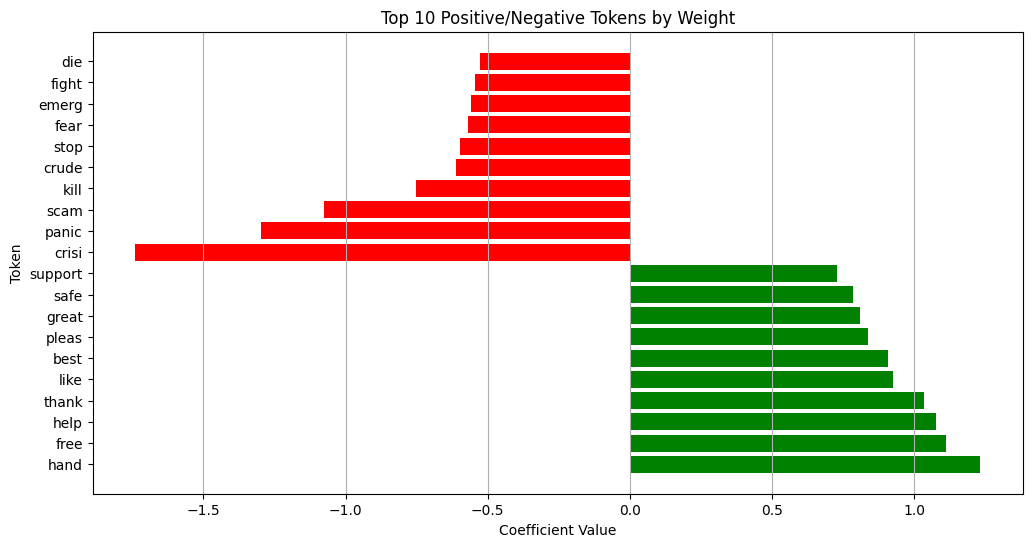

In [41]:
from sklearn.preprocessing import StandardScaler
train_vec = cv_df.fit_transform(train['OriginalTweet'])
scaler = StandardScaler(with_mean=False)
train_scaled = scaler.fit_transform(train_vec)

model = LogisticRegression(max_iter=1000)
model.fit(train_scaled, y_train)
y_pred = model.predict(train_scaled)
print(f"Accuracy после скалирования: {accuracy_score(y_train, y_pred):.3f}")

vocab = cv_df.get_feature_names_out()
coefs = model.coef_[0]
top_pos = np.argsort(coefs)[-10:][::-1]
top_neg = np.argsort(coefs)[:10]
df_weights = pd.DataFrame({
    'token': [vocab[i] for i in list(top_pos) + list(top_neg)],
    'weight': np.concatenate([coefs[top_pos], coefs[top_neg]]),
    'type': ['positive']*10 + ['negative']*10
})


plt.figure(figsize=(12, 6))
colors = ['green' if t == 'positive' else 'red' for t in df_weights['type']]
plt.barh(df_weights['token'], df_weights['weight'], color=colors)
plt.title('Top 10 Positive/Negative Tokens by Weight')
plt.xlabel('Coefficient Value')
plt.ylabel('Token')
plt.grid(axis='x')
plt.show()

**Ответ:** # -- YOUR ANSWER HERE --

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [50]:
print(len(train),train['UserName'].nunique(),
train['ScreenName'].nunique())# -- YOUR CODE HERE --

23410 23410 23410


**Ответ:** # -- YOUR ANSWER HERE --

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

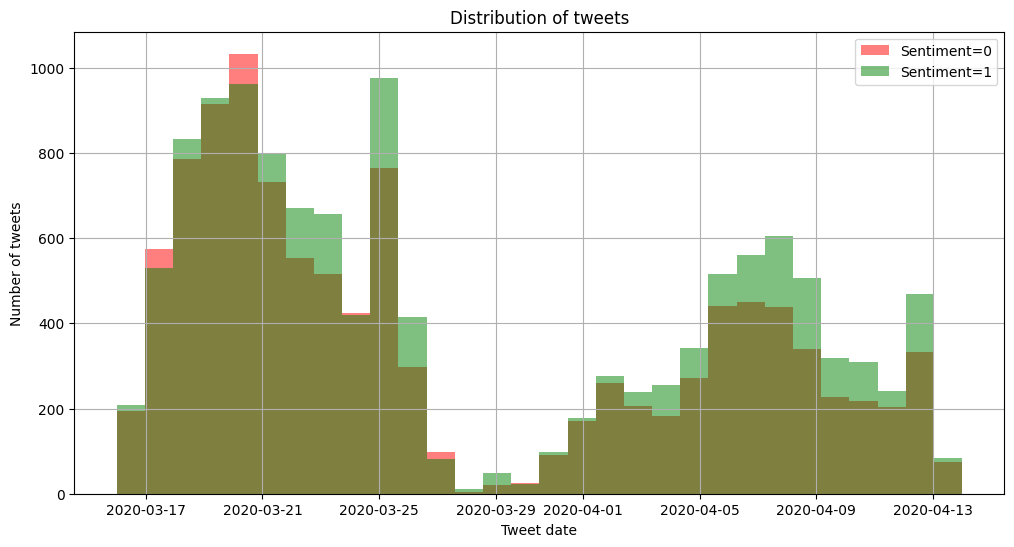

In [53]:
train['TweetAt']=pd.to_datetime(train['TweetAt'], format='%d-%m-%Y')
plt.figure(figsize=(12, 6))
for sentiment, color in zip([0, 1], ['red', 'green']):
    subset = train[train['Sentiment'] == sentiment]
    plt.hist(subset['TweetAt'], bins=30, color=color, alpha=0.5,
             label=f'Sentiment={sentiment}')
plt.xlabel('Tweet date')
plt.ylabel('Number of tweets')
plt.title('Distribution of tweets')
plt.legend()
plt.grid()
plt.show()# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [54]:
train['Location'].nunique()

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

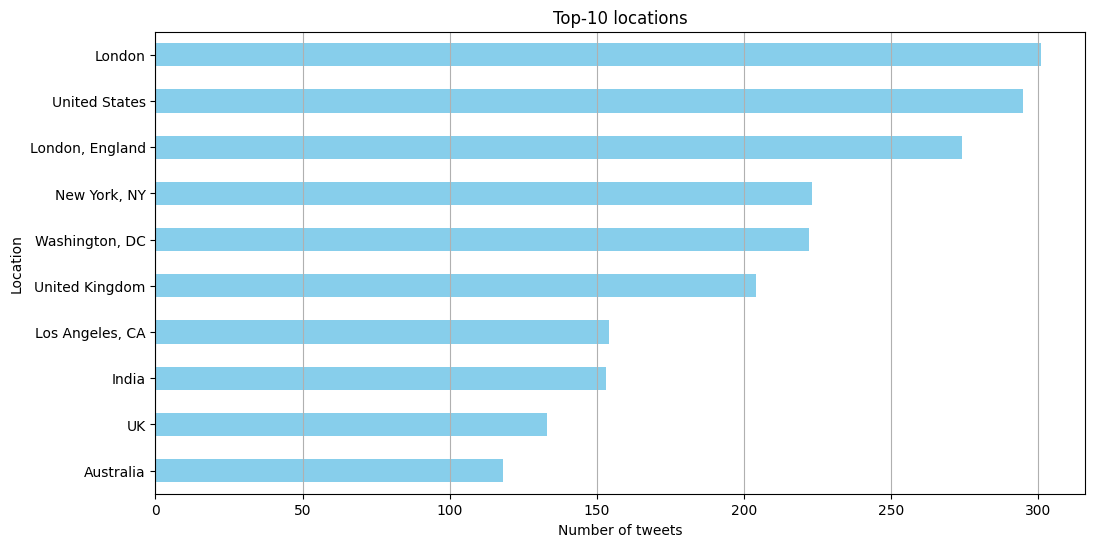

In [55]:
locations = train[train['Location'].isin(['Unknown', '']) == False]
top_locations = locations['Location'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_locations.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top-10 locations')
plt.xlabel('Number of tweets')
plt.ylabel('Location')
plt.grid(axis='x')
plt.show()# -- YOUR CODE HERE --

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

4766


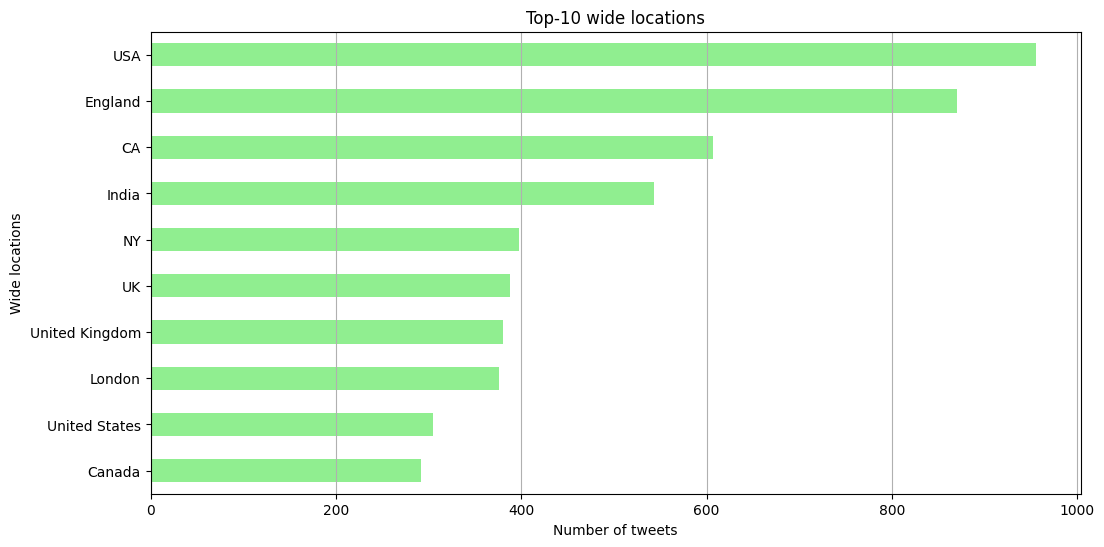

In [56]:
def get_location(loc):
    if pd.isna(loc) or loc in ['Unknown', '']:
        return 'Unknown'
    parts = [p.strip() for p in loc.split(',')]
    return parts[-1] if len(parts) > 1 else loc
train['WiderLocation'] = train['Location'].apply(get_location)
print(train['WiderLocation'].nunique())


known_wide = train[train['WiderLocation'] != 'Unknown']
top_wide_locations = known_wide['WiderLocation'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_wide_locations.sort_values().plot(kind='barh', color='lightgreen')
plt.title('Top-10 wide locations')
plt.xlabel('Number of tweets')
plt.ylabel('Wide locations')
plt.grid(axis='x')
plt.show()# -- YOUR CODE HERE --

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [48]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --